In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

In [29]:
P=5
alpha=0.01
sigma=1e7
mur=32
mu0=4*np.pi*1e-7
vol=26.833234653902096
N=3000
NPOD=50

In [30]:
# Select directory
directory="Results/CSG_Tetra/al_0.01_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_25919_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

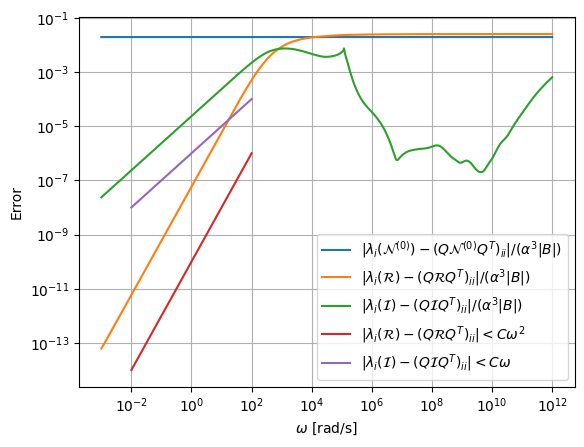

In [31]:
uinf,Qinf=np.linalg.eig(Minf)
myord=np.argsort(np.abs(uinf))
uinf=uinf[myord]
Qinf=Qinf[:,myord]

uN0,QN0=np.linalg.eig(N0)
myord=np.argsort(np.abs(uN0))
uN0=uN0[myord]
QN0=QN0[:,myord]
QN0=QN0[myord,:]

utest=np.transpose(Qinf)@np.real(N0)@Qinf
myord=np.argsort(np.diag(np.abs(utest)))
utest=utest[:,myord]
utest=utest[myord,:]

errorsN0=np.linalg.norm(uN0-np.diag(utest))*np.ones(len(Omega))
  

# Check the similarity of applying Qinf
errorsre=np.zeros(len(Omega))
errorsim=np.zeros(len(Omega))

for n in range(len(Omega)):
    lamre=np.real(Eigenvalues[n])
    Ten=TensorArray[n,:]
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=Ten[0]
    MPT[0,1]=Ten[1]
    MPT[0,2]=Ten[2]
    MPT[1,0]=Ten[3]
    MPT[1,1]=Ten[4]
    MPT[1,2]=Ten[5]
    MPT[2,0]=Ten[6]
    MPT[2,1]=Ten[7]
    MPT[2,2]=Ten[8]
    ure,Qre=np.linalg.eig(np.real(MPT-N0))
    myord=np.argsort(np.abs(ure))
    ure=ure[myord]
    #Qre=Qre[:,myord]
    uim,Qim=np.linalg.eig(np.imag(MPT))
    myord=np.argsort(uim)
    uim=uim[myord]
    #Qim=Qim[:,myord]
    # Compare
    #print(MPT)
    utest=np.transpose(Qinf)@np.real(MPT-N0)@Qinf
    myord=np.argsort(np.diag(np.abs(utest)))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    #errorsre[n]=np.linalg.norm(np.diag(ure)-np.diag(np.diag(utest)))
    errorsre[n]=np.linalg.norm(ure-np.diag(utest))
    
    #print(errorsre[n]/alpha**3/vol,ure,np.diag(utest))
    
    utest=np.transpose(Qinf)@np.imag(MPT)@Qinf
    myord=np.argsort(np.diag(utest))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    errorsim[n]=np.linalg.norm(uim-np.diag(utest))
    #print(errorsim[n]/alpha**3/vol,uim,np.diag(utest))
    
plt.figure()
plt.loglog(Omega,errorsN0/alpha**3/vol,label=r"$| \lambda_i({\cal N}^{(0)})-(Q{\cal N}^{(0)} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsre/alpha**3/vol,label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsim/alpha**3/vol,label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|/ (\alpha^3|B|)$")


#log error = 2*log omega +c
#c=log 1e-17-(log 1e-2)*2
c1=10**(np.log10(1e-14)-2*np.log10(1e-2))
line1=np.array(([[1e-2, 1e-14],[1e2, 10**(np.log10(1e2)*2+np.log10(c1) )]]))
plt.plot(line1[:,0],line1[:,1],label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|< C \omega^2$")
c2=10**(np.log10(1e-8)-np.log10(1e-2))
line2=np.array(([[1e-2, 1e-8],[1e2, 10**(np.log10(1e2)+np.log10(c2))]]))
plt.plot(line2[:,0],line2[:,1],label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|<  C \omega$")



plt.legend()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Error")
plt.grid()
plt.savefig("my_plots/tet_mpt/abserrplot_tet.pdf")

3000
3000
3000


/tmp/user/10925/ipykernel_1557450/2784188312.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


<Figure size 640x480 with 0 Axes>

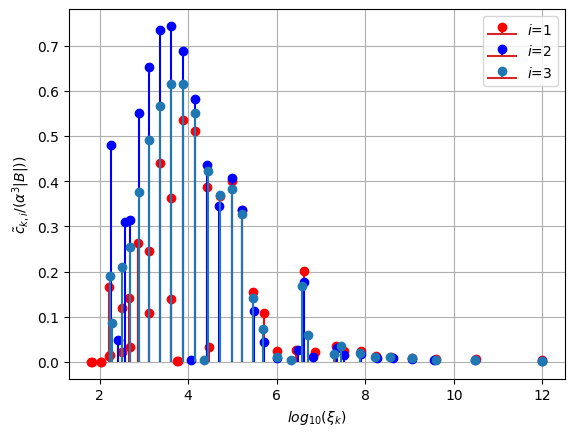

In [32]:
# Compare the modes and amplitudes
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    print(nfound)
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))

    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B|))$')

plt.grid()
plt.legend()
plt.savefig("my_plots/tet_mpt/amp_modes_ev3000.pdf")



/tmp/user/10925/ipykernel_1557450/1528046208.py:10: RuntimeWarning: divide by zero encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])
/tmp/user/10925/ipykernel_1557450/1528046208.py:10: RuntimeWarning: invalid value encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])


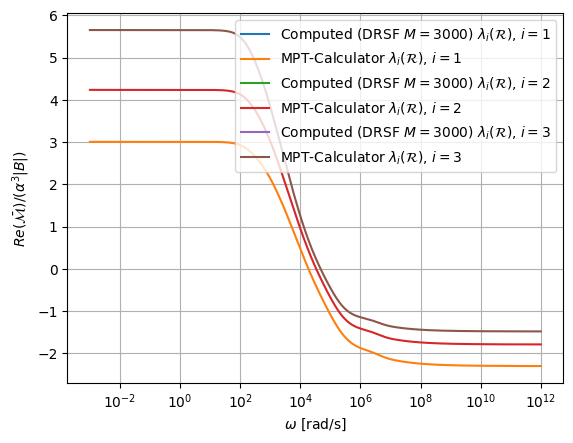

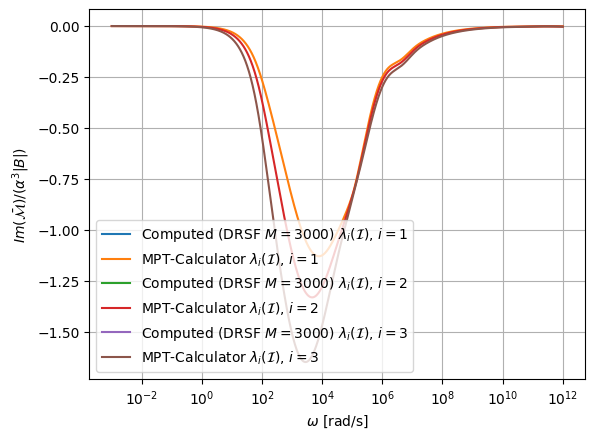

In [33]:
N=len(Omega)
for i in range(3):
    #DRSF=MPTinf_ob[i,i]*np.ones((N),dtype=complex)
    nfound=len(xi[:,0])
    ckp=ck[0:nfound,i]
    xip=xi[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    plt.figure(1)
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=3000$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    
    plt.figure(2)
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=3000$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal I})$, $i=$"+str(i+1))
                 
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()
plt.savefig("my_plots/tet_mpt/computed_realmpt_M3000_tet.pdf")

plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
plt.savefig("my_plots/tet_mpt/computed_imagmpt_M3000_tet.pdf")
plt.show()



<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_1557450/491489220.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Tetrahedron step, $\lambda_i$, $i$="+str(i+1))


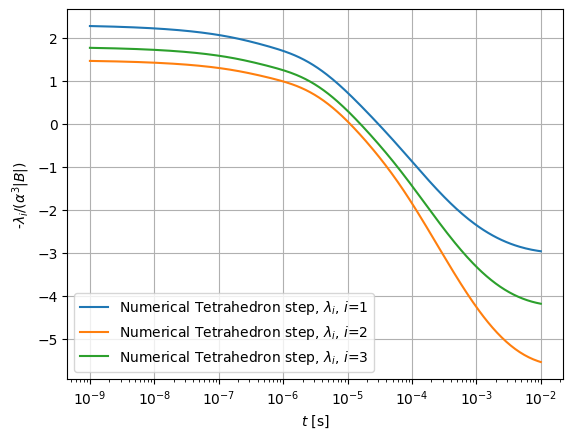

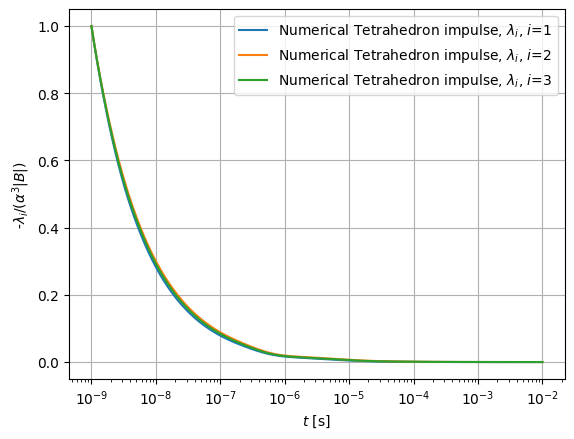

In [34]:
# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=vol*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Tetrahedron step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3|B|)$")
plt.savefig("my_plots/tet_mpt/tet_step_semilog.pdf")




plt.figure(2)
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,label=r"Numerical Tetrahedron impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3 |B|)$")
plt.savefig("my_plots/tet_mpt/tet_impulse_semilog.pdf")
plt.show()


In [362]:
from Functions.Core_Spectrum.getimpulse_step import *


In [363]:
# remove scaling
TensorArrayn=TensorArray#/(2*np.pi*alpha**3)
Minfn = Minf #/(2*np.pi*alpha**3)

#Minfn=-1*np.eye(3)
xi_iter, ck_iter, Nfound_iter = PolesandAmp(Omega,np.conj(TensorArrayn),Minfn, Iterative_refine=False)
ck_iter=ck_iter#*(2*np.pi*alpha**3)

[-6.16966757e-08 -3.96969408e-08 -4.79591952e-08]
NNLS Solution residual 6.0221404047879e-05
Found25terms
c=[-6.18752952e-08  5.27096517e-09  5.26553916e-09  6.45109834e-09
  8.70709720e-09  1.07331526e-08  1.15775318e-08  2.50337574e-09
  1.27870737e-08  1.36473363e-08  1.33910467e-08  1.17343199e-08
  9.77677144e-09  8.17653410e-09  3.76011626e-09  3.44305087e-09
  3.69654568e-09  2.84110599e-09  2.48691872e-09  1.93903978e-09
  1.42772806e-09  1.09519115e-09  5.30290742e-10  1.23946524e-09
  2.13458257e-10]
xi=[0.00000000e+00 1.67055347e+04 3.41440867e+04 5.77899644e+04
 9.98180822e+04 1.76151374e+05 3.10101090e+05 4.24744762e+05
 5.90366760e+05 1.06832635e+06 2.00937370e+06 3.77388547e+06
 7.69472936e+06 1.48387681e+07 2.97502873e+07 3.85334655e+07
 7.13872171e+07 1.29562097e+08 2.53928468e+08 5.48167106e+08
 1.25749027e+09 3.21032905e+09 8.18223344e+09 4.13116362e+10
 1.00000000e+12]
NNLS Solution residual 7.506649070095038e-05
Found24terms
c=[-3.99888719e-08  1.32718162e-08  1.04

/tmp/user/10925/ipykernel_3186400/307320212.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3186400/307320212.py:24: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


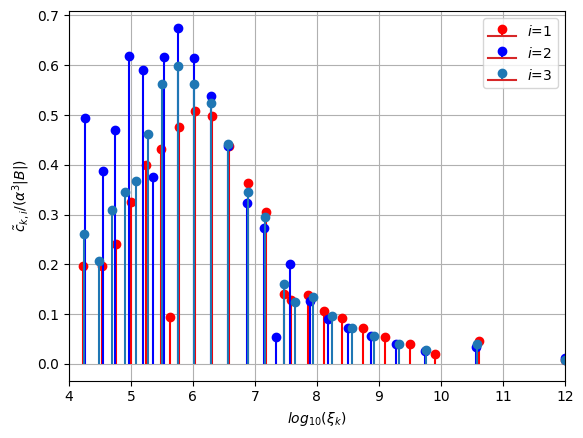

<Figure size 640x480 with 0 Axes>

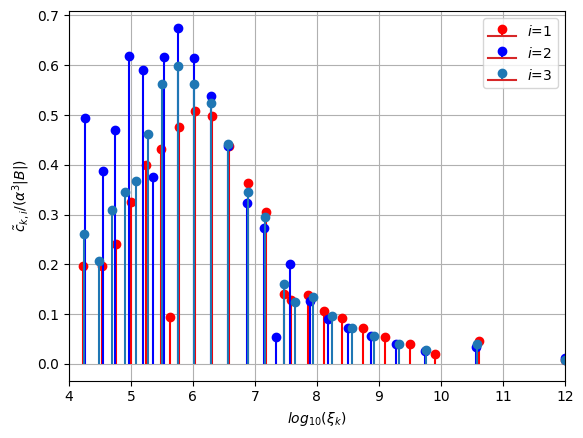

In [364]:
plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(3):
    nfound=len(xi_iter[:,i])
    ckp=ck_iter[0:nfound,i]
    xip=xi_iter[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')

plt.grid()
plt.xlim(4,12)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
    

plt.grid()
plt.xlim(4,12)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
plt.show()

In [387]:
# Compare tet and ellipsoid spectrums
# Tet
P=5
alpha=0.001
sigma=1e7
mur=32
mu0=4*np.pi*1e-7
vol=26.833234653902096
N=3000
NPOD=50

directory="Results/CSG_Tetra/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_25794_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

cktet=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xitet=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegatet=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArraytet= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluestet=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minftet= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0tet= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

# Ellipsoid - minf
# Note this has been recalculated with linear geometry to ensure convergence of solution. Note issues with curved geometry and p>=5.
P=2
NPOD=50
#directory="Results/OCC_ellipsoid_Tetra_Minf/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_15856_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
print(directory)
#directory="Results/OCC_ellipsoid_Tetra_Minf/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_66676_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
#directory="Results/OCC_ellipsoid_Tetra_Minf/al_0.001_mu_32_sig_1e7/1e-2-1e13_"+str(N)+"_el_15856_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
directory="Results/CSG_ellipsoid_Tetra_Minf/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_22976_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

ckminf=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
ximinf=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegaminf=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayminf= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesminf=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfminf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0minf= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

print(directory)

#Results/OCC_ellipsoid_Tetra_N0/al_0.001_mu_32_sig_1e7/1e-3-1e12_3000_el_17146_ord_3_POD_50_1e-6
P=3
NPOD=50
#directory="Results/OCC_ellipsoid_Tetra_N0/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_17146_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
#directory="Results/OCC_ellipsoid_Tetra_N0/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_77574_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
directory="Results/CSG_ellipsoid_Tetra_N0/al_0.001_mu_32_sig_1e7/1e-3-1e12_"+str(N)+"_el_24634_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

ckn0=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xin0=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omegan0=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArrayn0= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluesn0=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfn0= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0n0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')
print(N0tet,N0n0)

Results/CSG_Tetra/al_0.001_mu_32_sig_1e7/1e-3-1e12_3000_el_25794_ord_5_POD_50_1e-6
Results/CSG_ellipsoid_Tetra_Minf/al_0.001_mu_32_sig_1e7/1e-3-1e12_3000_el_22976_ord_2_POD_50_1e-6
[[ 1.41379896e-07  2.13567479e-08 -1.26825455e-08]
 [ 2.13567479e-08  9.34790712e-08  7.66093197e-09]
 [-1.26825455e-08  7.66093197e-09  1.11198980e-07]] [[ 1.50978340e-07 -1.24337569e-12 -3.96030104e-12]
 [-1.24337569e-12  1.13142947e-07 -2.87908149e-13]
 [-3.96030104e-12 -2.87908149e-13  8.03710893e-08]]


/tmp/user/10925/ipykernel_3186400/303520429.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3186400/303520429.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_3186400/303520429.py:46: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


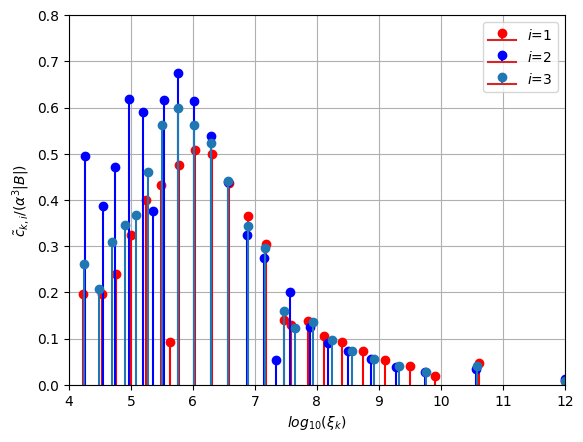

<Figure size 640x480 with 0 Axes>

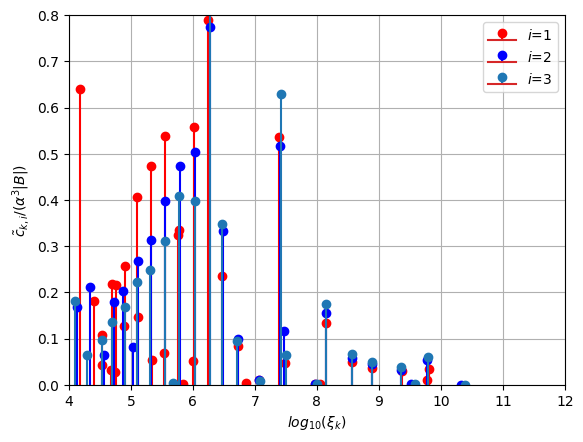

<Figure size 640x480 with 0 Axes>

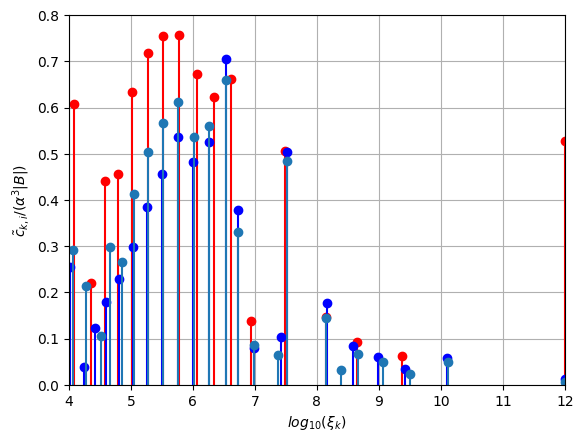

In [388]:
plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(3):
    nfound=len(xitet[:,i])
    ckp=cktet[0:nfound,i]
    xip=xitet[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')

plt.grid()
plt.xlim(4,12)
plt.ylim(0,0.8)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(ximinf[:,i])
    ckp=ckminf[0:nfound,i]
    xip=ximinf[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
    
#print(ckminf)
plt.grid()
plt.xlim(4,12)
plt.ylim(0,0.8)

plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
#plt.show()
plt.savefig("my_plots/tet_mpt/amp_modes_ev3000minf.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xin0[:,i])
    ckp=ckn0[0:nfound,i]
    xip=xin0[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
plt.grid()
plt.xlim(4,12)
plt.ylim(0,0.8)

plt.savefig("my_plots/tet_mpt/amp_modes_ev3000n0.pdf")

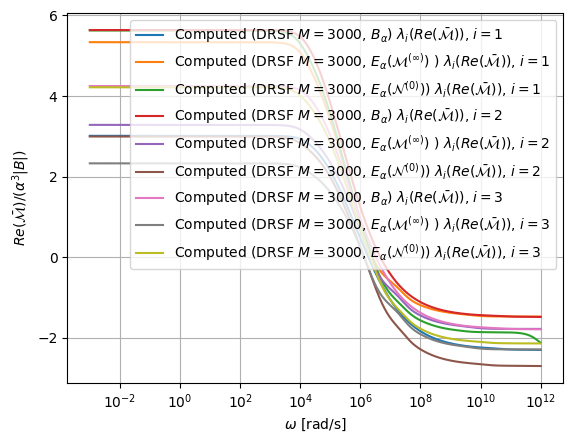

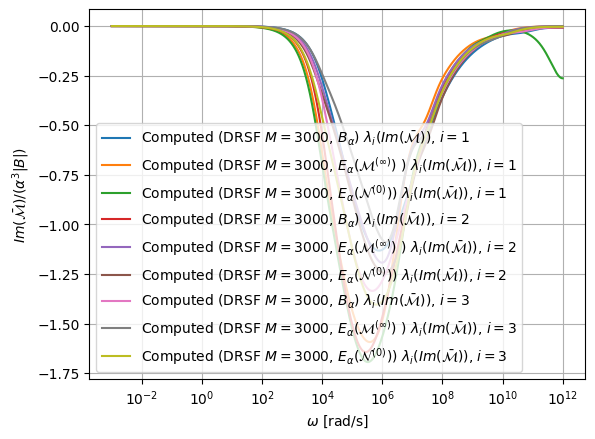

In [389]:
N=len(Omega)
for i in range(3):
    #DRSF=Minftet[i,i]*np.ones((N),dtype=complex)
    nfound=len(xitet[:,i])
    ckp=cktet[0:nfound,i]
    xip=xitet[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0:
            DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    #print(xitet)
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    nfound=len(xitet[:,i])
    ckp=ckminf[0:nfound,i]
    xip=ximinf[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSFminf=(ckp[0])*np.ones((N),dtype=complex)
    DRSFminf=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0:
            DRSFminf+=ckp[n]/(1+1j*Omega/xip[n])

    nfound=len(xin0[:,i])
    ckp=ckn0[0:nfound,i]
    xip=xin0[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    #DRSFn0=Minfn0[i,i]*np.ones((N),dtype=complex)
    DRSFn0=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        if xip[n] != 0 :#and xip[n] < 1e10:
            DRSFn0+=ckp[n]/(1+1j*Omega/xip[n])
    
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $B_\alpha$) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(DRSFminf)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal M}^{(\infty)})$ ) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(DRSFn0)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal N}^{(0)})$) $\lambda_i(Re(\bar{\cal M}))$, $i=$"+str(i+1))
    
    #plt.semilogx(Omega,np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.real(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))


    
    plt.figure(2)
    #plt.semilogx(Omega,-np.imag(Eigenvaluestet[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,-np.imag(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i(\bar{\cal M})$, $i=$"+str(i+1))
    #plt.semilogx(Omega,np.imag(DRSFn0)/(alpha**3*vol),label=r"Computed (DRSF $M=500$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $B_\alpha$) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSFminf)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal M}^{(\infty)})$ ) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.imag(DRSFn0)/(alpha**3*vol),'-',label=r"Computed (DRSF $M=3000$, $E_\alpha({\cal N}^{(0)})$) $\lambda_i(Im(\bar{\cal M}))$, $i=$"+str(i+1))
               
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()
plt.savefig("my_plots/tet_mpt/ellip_computed_realmpt_M3000_tet.pdf")


plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
plt.savefig("my_plots/tet_mpt/ellip_computed_imagmpt_M3000_tet.pdf")
plt.show()

[[-4.35077819e-08  6.67442288e-09 -4.70048597e-09]
 [ 6.67442288e-09 -5.65124342e-08  3.79730399e-09]
 [-4.70048597e-09  3.79730399e-09 -4.93325956e-08]] [-3.95150070e-08+1.20445954e-11j  9.20537603e-13+6.85650046e-15j
 -7.78653448e-13-2.94957200e-15j  9.20537603e-13+6.85650046e-15j
 -4.77552471e-08+1.39825944e-11j  1.37002910e-12+5.38302651e-15j
 -7.78653448e-13-2.94957200e-15j  1.37002910e-12+5.38302651e-15j
 -6.14000284e-08+1.59733240e-11j] [[-3.95151683e-08  9.20906932e-13 -7.76427985e-13]
 [ 9.20906932e-13 -4.77549182e-08  1.37168712e-12]
 [-7.76427985e-13  1.37168712e-12 -6.13998910e-08]]
Ellipsoid volume 32.1283873320766


(-0.3, 0.3)

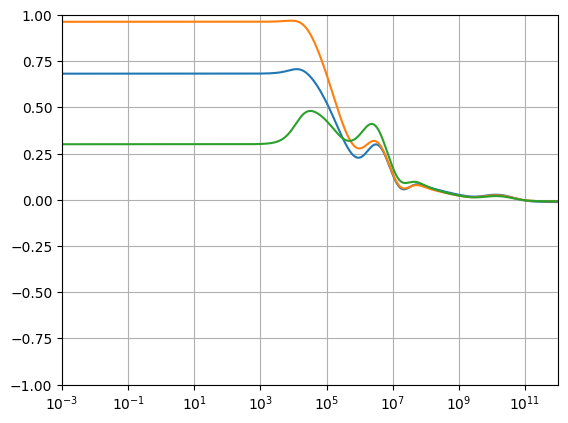

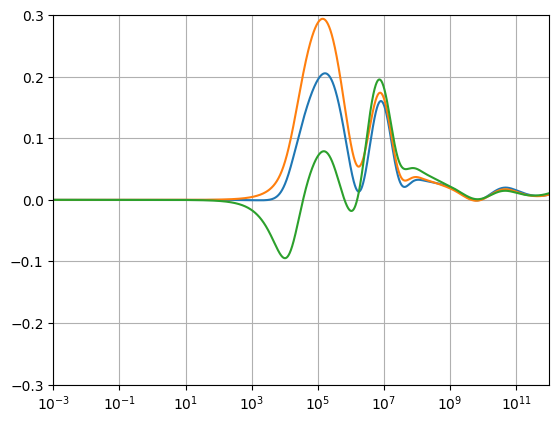

In [379]:
N=len(Omega)
dum,Q=np.linalg.eig(Minftet)
ord=np.argsort(dum)
Qs=Q[:,ord]
dum=dum[ord]
#print(dum,ord)
#print(np.diag(np.transpose(Qs)@Minftet@Qs))
dum,Qminf=np.linalg.eig(Minfminf)
ord=np.argsort(dum)
Qsminf=Qminf[:,ord]


print(Minftet,TensorArrayminf[-1,:],Minfminf)
r1 = 2.93348328
r2 = 1.90849167
r3 = 1.3700185
print("Ellipsoid volume",np.pi *4/3*r1*r2*r3)
#print(dum,np.diag(Q@Minfminf@np.transpose(Q)),np.linalg.eig(Minfminf))

# Compute eigenvalues based on Q
for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArraytet[n,0]
    MPT[0,1]=TensorArraytet[n,1]
    MPT[0,2]=TensorArraytet[n,2]
    MPT[1,0]=TensorArraytet[n,3]
    MPT[1,1]=TensorArraytet[n,4]
    MPT[1,2]=TensorArraytet[n,5]
    MPT[2,0]=TensorArraytet[n,6]
    MPT[2,1]=TensorArraytet[n,7]
    MPT[2,2]=TensorArraytet[n,8]
    Eigenvaluestet[n,:]=np.diag(np.transpose(Qs)@MPT@Qs)
    MPT[0,0]=TensorArrayminf[n,0]
    MPT[0,1]=TensorArrayminf[n,1]
    MPT[0,2]=TensorArrayminf[n,2]
    MPT[1,0]=TensorArrayminf[n,3]
    MPT[1,1]=TensorArrayminf[n,4]
    MPT[1,2]=TensorArrayminf[n,5]
    MPT[2,0]=TensorArrayminf[n,6]
    MPT[2,1]=TensorArrayminf[n,7]
    MPT[2,2]=TensorArrayminf[n,8]
    Eigenvaluesminf[n,:]=np.diag(np.transpose(Qsminf)@MPT@Qsminf)
    


for i in range(3):



    
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol)-np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

    
   
    plt.figure(2)
    plt.semilogx(Omega,np.imag(Eigenvaluestet[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))


plt.figure(1)
plt.grid()
plt.xlim([1e-3,1e12])
plt.ylim([-1,1])

plt.figure(2)
plt.grid()
plt.xlim([1e-3,1e12])
plt.ylim([-0.3,0.3])

[8.06881174e-08+8.21969645e-16j 1.13685252e-07+1.12265390e-15j
 1.51684577e-07+1.67883301e-15j] [8.03710890e-08+1.28098481e-15j 1.13142947e-07+1.61698554e-15j
 1.50978340e-07+2.48303980e-15j] [[ 1.41379896e-07  2.13567479e-08 -1.26825455e-08]
 [ 2.13567479e-08  9.34790712e-08  7.66093197e-09]
 [-1.26825455e-08  7.66093197e-09  1.11198980e-07]] [[ 1.50978340e-07 -1.24337569e-12 -3.96030104e-12]
 [-1.24337569e-12  1.13142947e-07 -2.87908149e-13]
 [-3.96030104e-12 -2.87908149e-13  8.03710893e-08]]


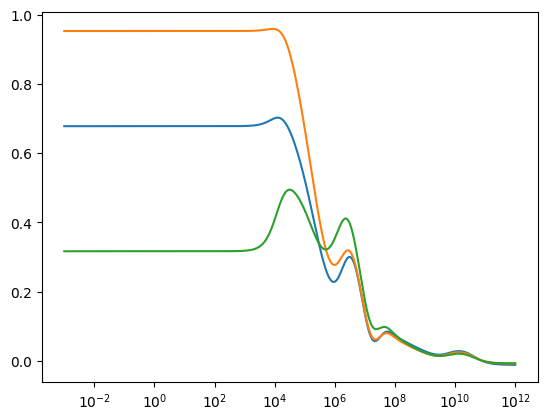

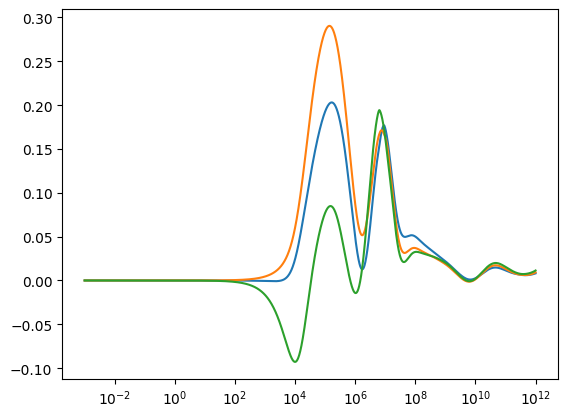

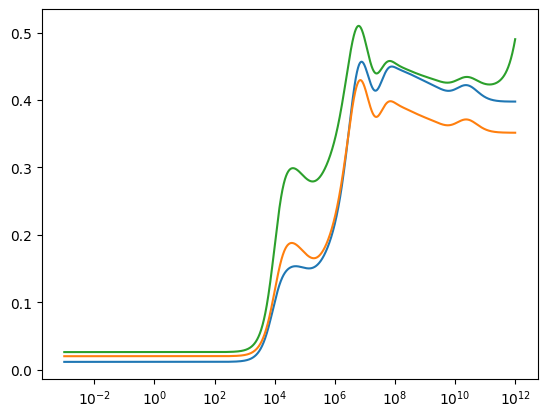

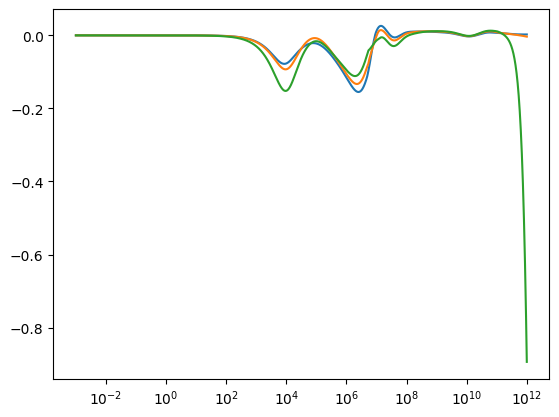

In [396]:

# Compute eigenvalues based on Q
for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArraytet[n,0]
    MPT[0,1]=TensorArraytet[n,1]
    MPT[0,2]=TensorArraytet[n,2]
    MPT[1,0]=TensorArraytet[n,3]
    MPT[1,1]=TensorArraytet[n,4]
    MPT[1,2]=TensorArraytet[n,5]
    MPT[2,0]=TensorArraytet[n,6]
    MPT[2,1]=TensorArraytet[n,7]
    MPT[2,2]=TensorArraytet[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    
    Eigenvaluestet[n,:]=reig+1j*ieig
    MPT[0,0]=TensorArrayminf[n,0]
    MPT[0,1]=TensorArrayminf[n,1]
    MPT[0,2]=TensorArrayminf[n,2]
    MPT[1,0]=TensorArrayminf[n,3]
    MPT[1,1]=TensorArrayminf[n,4]
    MPT[1,2]=TensorArrayminf[n,5]
    MPT[2,0]=TensorArrayminf[n,6]
    MPT[2,1]=TensorArrayminf[n,7]
    MPT[2,2]=TensorArrayminf[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    Eigenvaluesminf[n,:]=reig+1j*ieig
for i in range(3):    
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol)-np.real(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

    
   
    plt.figure(2)
    plt.semilogx(Omega,np.imag(Eigenvaluestet[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesminf[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArraytet[n,0]
    MPT[0,1]=TensorArraytet[n,1]
    MPT[0,2]=TensorArraytet[n,2]
    MPT[1,0]=TensorArraytet[n,3]
    MPT[1,1]=TensorArraytet[n,4]
    MPT[1,2]=TensorArraytet[n,5]
    MPT[2,0]=TensorArraytet[n,6]
    MPT[2,1]=TensorArraytet[n,7]
    MPT[2,2]=TensorArraytet[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    
    Eigenvaluestet[n,:]=reig+1j*ieig
    MPT[0,0]=TensorArrayn0[n,0]
    MPT[0,1]=TensorArrayn0[n,1]
    MPT[0,2]=TensorArrayn0[n,2]
    MPT[1,0]=TensorArrayn0[n,3]
    MPT[1,1]=TensorArrayn0[n,4]
    MPT[1,2]=TensorArrayn0[n,5]
    MPT[2,0]=TensorArrayn0[n,6]
    MPT[2,1]=TensorArrayn0[n,7]
    MPT[2,2]=TensorArrayn0[n,8]
    reig,dum=np.linalg.eig(np.real(MPT))
    reig=np.sort(reig)
    ieig,dum=np.linalg.eig(np.imag(MPT))
    ieig=np.sort(ieig)
    Eigenvaluesn0[n,:]=reig+1j*ieig
for i in range(3):    
    plt.figure(3)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol)-np.real(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

    
   
    plt.figure(4)
    plt.semilogx(Omega,np.imag(Eigenvaluestet[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
print(Eigenvaluestet[0,:],Eigenvaluesn0[0,:],N0tet,N0n0)
#print(np.real(Eigenvaluestet[:,0])/(alpha**3*vol)-np.real(Eigenvaluesn0[:,0])/(alpha**3*vol))

[[ 1.41379896e-07  2.13567479e-08 -1.26825455e-08]
 [ 2.13567479e-08  9.34790712e-08  7.66093197e-09]
 [-1.26825455e-08  7.66093197e-09  1.11198980e-07]]
[[ 1.50978340e-07 -1.24337569e-12 -3.96030104e-12]
 [-1.24337569e-12  1.13142947e-07 -2.87908149e-13]
 [-3.96030104e-12 -2.87908149e-13  8.03710893e-08]]
[[ 8.06881174e-08+8.22190856e-16j  1.13685252e-07+1.12251522e-15j
   1.51684577e-07+1.67875047e-15j]
 [ 8.06881174e-08+8.31613606e-16j  1.13685252e-07+1.13546751e-15j
   1.51684577e-07+1.69818405e-15j]
 [ 8.06881174e-08+8.41146210e-16j  1.13685252e-07+1.14857018e-15j
   1.51684577e-07+1.71784282e-15j]
 ...
 [-6.16724585e-08+2.54271896e-10j -4.79174057e-08+2.36225940e-10j
  -3.98084774e-08+3.08239024e-10j]
 [-6.16725784e-08+2.56432290e-10j -4.79174539e-08+2.38013067e-10j
  -3.98085075e-08+3.10629476e-10j]
 [-6.16726960e-08+2.58638960e-10j -4.79175010e-08+2.39836371e-10j
  -3.98085368e-08+3.13059828e-10j]]


(-0.25, 0.25)

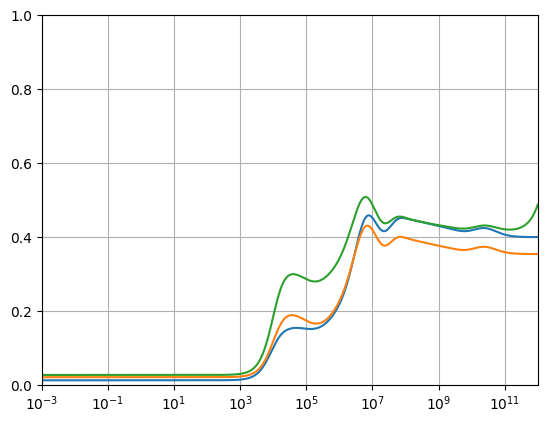

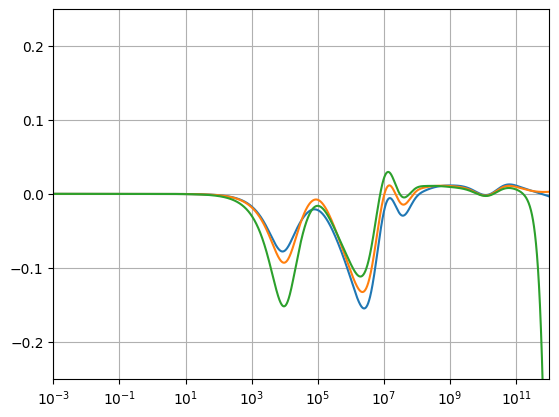

In [381]:
N=len(Omega)
dum,Q=np.linalg.eig(N0tet)
ord=np.argsort(dum)
Qs=Q[:,ord]
dum=dum[ord]

dum,Qn0=np.linalg.eig(N0n0)
ord=np.argsort(dum)
Qsn0=Qn0[:,ord]
print(N0tet)
print(N0n0)


#print(Minftet,Minfminf)
#print(dum,np.diag(Q@Minfminf@np.transpose(Q)),np.linalg.eig(Minfminf))

# Compute eigenvalues based on Q
for n in range(N):
    
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=TensorArraytet[n,0]
    MPT[0,1]=TensorArraytet[n,1]
    MPT[0,2]=TensorArraytet[n,2]
    MPT[1,0]=TensorArraytet[n,3]
    MPT[1,1]=TensorArraytet[n,4]
    MPT[1,2]=TensorArraytet[n,5]
    MPT[2,0]=TensorArraytet[n,6]
    MPT[2,1]=TensorArraytet[n,7]
    MPT[2,2]=TensorArraytet[n,8]
    Eigenvaluestet[n,:]=np.diag(np.transpose(Qs)@MPT@Qs)
    
    MPT[0,0]=TensorArrayn0[n,0]
    MPT[0,1]=TensorArrayn0[n,1]
    MPT[0,2]=TensorArrayn0[n,2]
    MPT[1,0]=TensorArrayn0[n,3]
    MPT[1,1]=TensorArrayn0[n,4]
    MPT[1,2]=TensorArrayn0[n,5]
    MPT[2,0]=TensorArrayn0[n,6]
    MPT[2,1]=TensorArrayn0[n,7]
    MPT[2,2]=TensorArrayn0[n,8]
    Eigenvaluesn0[n,:]=np.diag(np.transpose(Qsn0)@MPT@Qsn0)
print(Eigenvaluestet)
for i in range(3):



    
    plt.figure(1)
    #plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),'x',label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvaluestet[:,i])/(alpha**3*vol)-np.real(Eigenvaluesn0[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    
   

    plt.figure(2)
    plt.semilogx(Omega,(np.imag(Eigenvaluestet[:,i])/(alpha**3*vol)-np.imag(Eigenvaluesn0[:,i])/(alpha**3*vol)),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))

plt.figure(1)
plt.grid()
plt.xlim([1e-3,1e12])
plt.ylim([0,1])
plt.figure(2)
plt.grid()
plt.xlim([1e-3,1e12])
plt.ylim([-0.25,0.25])

/tmp/user/10925/ipykernel_3186400/2033190796.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  Minf_n0diff[0,0]=-Ten_n0diff[-1,0]
/tmp/user/10925/ipykernel_3186400/2033190796.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  Minf_n0diff[1,1]=-Ten_n0diff[-1,4]
/tmp/user/10925/ipykernel_3186400/2033190796.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  Minf_n0diff[2,2]=-Ten_n0diff[-1,8]


[-1.07174083e-08 -9.48464130e-09 -1.30577888e-08]
NNLS Solution residual 0.18949552902368758
NNLS Solution residual 0.18386593708848523
NNLS Solution residual 0.1686117874855788
Found2terms
c=[3.74977411e-10 5.81233491e-09]
xi=[0.e+00 1.e+12]
[[0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e+12]
 [0.e+00 0.e+00 0.e+00]
 ...
 [0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00]] [[5.17622880e-09 4.90567751e-09 3.74977411e-10]
 [0.00000000e+00 0.00000000e+00 5.81233491e-09]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]


/tmp/user/10925/ipykernel_3186400/2033190796.py:20: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


(4.0, 12.0)

<Figure size 640x480 with 0 Axes>

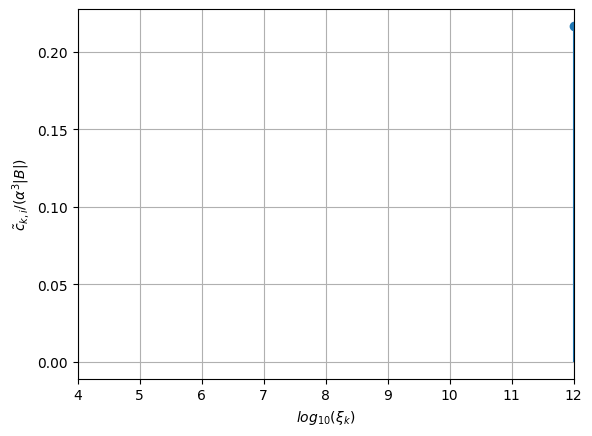

In [382]:
Ten_n0diff=np.zeros((N,9),dtype=complex)
Minf_n0diff=np.eye(3) # dummy to prevent reorganising
for n in range(N):
    Ten_n0diff[n,0]=np.abs(np.real((Eigenvaluestet[n,0]- Eigenvaluesn0[n,0])))+1j*np.abs(np.imag((Eigenvaluestet[n,0]- Eigenvaluesn0[n,0]))) #/(alpha**3*vol)
    Ten_n0diff[n,4]=np.abs(np.real((Eigenvaluestet[n,1]- Eigenvaluesn0[n,1])))+1j*np.abs(np.imag((Eigenvaluestet[n,1]- Eigenvaluesn0[n,1])))#/(alpha**3*vol)
    Ten_n0diff[n,8]=np.abs(np.real((Eigenvaluestet[n,2]- Eigenvaluesn0[n,2])))+1j*np.abs(np.imag((Eigenvaluestet[n,2]- Eigenvaluesn0[n,2])))#/(alpha**3*vol)
Minf_n0diff[0,0]=-Ten_n0diff[-1,0]
Minf_n0diff[1,1]=-Ten_n0diff[-1,4]
Minf_n0diff[2,2]=-Ten_n0diff[-1,8]

xi_n0diff, ck_n0diff, Nfound_n0diff = PolesandAmp(Omega,np.conj(Ten_n0diff),Minf_n0diff, Iterative_refine=False)
print(xi_n0diff,ck_n0diff)
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi_n0diff[:,i])
    ckp=ck_n0diff[0:nfound,i]
    xip=xi_n0diff[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B| )$')
plt.grid()
plt.xlim(4,12)